# GPT2 Experiments

## Introduction

My initial set of experiments involved implementing the MLA inspired extension for the attention output projection matrix $W^O$, to both the MHA and MLA attention variants and subsequently evaluating across a set of different $kv$, $q$ and $o$ compression dimensions for a reduced scale BERT and GPT2 models. While the results were promising across both the reduced scale BERT and GPT2 models, no trained model with compression outperformed their corresponding MHA baselines. Some variants did approach similar levels of performance, which is commendable at this scale especially given the majority of the models trainable weights are embedding parameters. As such I felt that it might be worth scaling the experiment to GPT2-small scale or larger. The main issue is this would most likely require the renting of external GPUs and could potentially be expensive. 

As such I wanted to explore the benefits of scaling via a cheaper proxy experiment before deciding whether to invest in scaling the model. The idea behind the first experiment is to take already trained GPT2 models of different sizes (small, medium and large) and replace their respective output projection matrices $W^O$ with an SVD reduced rank matrix. Essentially, I wish to replicate my experiment on these larger models without the need to pretrain from scratch. Therefore, for each layer in the respective model:

1. SVD is applied to that layers output projection matrix $W^O$, decomposing it into its singular values and singular vectors.
2. A set of $r$ fraction are defined, each is multiplied by matrix's full rank ($d_{model}$) to give the number of largest singular values to retain. These top $r$ singular values and their vectors form the best rank $r$ approxmation of $W^O$.
3. $W^O$ will then be replaced by this best rank $r$ approximation matrix, which can be stored as two smaller matrices of shape $d_{model} \times r$ and $r \times d_{model}$, directly mirroring the down and up projection matrices.

The idea being that this will approximate how my MLA inspired extention will function at a larger scale. This is not an exact replica of my MLA mechanism but should approximate the MHAE implementation, by testing if $W^O$ is low rank compressible on larger trained models.

After the matrix has been replaced by its best rank approximation matrix, the perplexity of the model will be evaluated on the `wikitext-103-raw-v1` validation dataset. Given none of these models have been trained with the best rank approximation matrices it is necessary to settle the new addition by continuing to pretrain the model on the `wikitext-103-raw-v1` training dataset. After a small number of steps, in this case 200, the perplexity will be evaluated again on the `wikitext-103-raw-v1` validation dataset.

A set of unchanged GPT2 small, medium and large models will also be evaluated on the `wikitext-103-raw-v1` validation dataset and will act as a set of baselines to compare against. 

Therefore, for each model the set of $r$ values [1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125] will be analysed with perplexity captured both pre and post additional pretraining. These values will form a perplexity curve for each model. This will show how each model performs with higher and higher levels of compression, from 50% to 3.125% of the original rank (singular values) retained (where $r=1$ represents the baseline model). These curves will also be normalised by their respective baseline models perplexity value, therefore, allowing a true comparison across the different models. These normalised curves will allow me to compare the rate of increase in perplexity as the level of compression increases. To be through I will be plotting raw and normalised curves from both pre and post continued pretraining of each model.

At an individual model level, the positive result would be that the curves remain flat for as long as possible, suggesting that there is redundancy present in the $W^O$ matrix and that perplexity remains stable as the level of compression increases. However, I would expect to see some level of uptick in perplexity as the level of compression increases. Across curves, the ideal result would be that the rate of increase of the perplexity would differ across models, with larger models increasing more slowly than smaller models.

## Define the necessary libraries

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import NullLocator

In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## Import the dataset

In [3]:
# Define the data path
data_path = "data/svd_probe_results.csv"

In [4]:
# Import the dataset
df = pd.read_csv(data_path).drop_duplicates(subset=["model", "r"], keep="last").sort_values("r").reset_index(drop=True)

In [5]:
# Examine the dataset
df.head()
df.tail()
df.shape

,model,r,actual_loss,actual_ppl,pretraining_loss,pretraining_ppl
0,gpt2-medium,0.03125,6.226871,506.169350,3.772930,43.507358
1,gpt2,0.03125,7.008114,1105.566926,4.398792,81.352520
2,gpt2-large,0.03125,7.734977,2286.955094,3.445632,31.363112
3,gpt2,0.06250,6.630466,757.835050,3.888921,48.858162
4,gpt2-large,0.06250,6.116286,453.178667,3.050893,21.134208


,model,r,actual_loss,actual_ppl,pretraining_loss,pretraining_ppl
13,gpt2,0.5,3.490525,32.803150,3.119757,22.640881
14,gpt2-medium,0.5,3.149038,23.313615,2.804345,16.516247
15,gpt2-medium,1.0,3.102086,22.244309,2.790142,16.283336
16,gpt2-large,1.0,2.957035,19.240845,2.632295,13.905650
17,gpt2,1.0,3.417048,30.479309,3.096450,22.119277


(18, 6)

In [6]:
# Precompute normalised columns
base_ppl = df[df["r"] == 1.0].set_index("model")["actual_ppl"]
df = df.assign(
    norm_pre=df.apply(lambda x: x["actual_ppl"] / base_ppl.get(x["model"]), axis=1),
    norm_post=df.apply(lambda x: x["pretraining_ppl"] / base_ppl.get(x["model"]), axis=1),
)

## Plotting Utils

In [7]:
def plot_results(df: pd.DataFrame, save_path="data/svd_probe_plot.png"):
    """
    Plot the results of the test run and compare the perplexity values across different levels of r (rank fraction).
    """
    colours = {
        "gpt2": "#1f77b4",
        "gpt2-medium": "#ff7f0e",
        "gpt2-large": "#2ca02c",
    }

    # Plotting
    fig, axes = plt.subplots(4, 1, figsize=(12, 20))
    ax_raw_pre, ax_raw_post, ax_norm_pre, ax_norm_post = axes
    label = lambda m, d: m
    for m in sorted(df["model"].unique()):
        d = df[df["model"] == m].sort_values("r")
        ax_raw_pre.plot(d["r"], d["actual_ppl"], "-o", color=colours[m], label=label(m, d))
        ax_raw_post.plot(d["r"], d["pretraining_ppl"], "-o", color=colours[m], label=label(m, d))
        ax_norm_pre.plot(d["r"], d["norm_pre"], "-o", color=colours[m])
        ax_norm_post.plot(d["r"], d["norm_post"], "-o", color=colours[m])

    ax_raw_pre.set_title("Raw perplexity - pre-continued pretraining")
    ax_raw_post.set_title("Raw perplexity - post-continued pretraining")
    ax_norm_pre.set_title("Normalised to full rank - pre-continued pretraining")
    ax_norm_post.set_title("Normalised to full rank - post-continued pretraining")

    r_vals = sorted(df["r"].unique(), reverse=True)
    for ax in axes:
        ax.set_xscale("log", base=2)
        ax.grid(True, alpha=0.3)
        ax.set_xticks(r_vals)
        ax.set_xticklabels([f"{r:g}" for r in r_vals])
        ax.xaxis.set_minor_locator(NullLocator())
        ax.set_xlim(1.05, df["r"].min() * 0.85)
        ax.set_xlabel("rank fraction r / d_model")

    for ax in (ax_raw_pre, ax_raw_post):
        ax.set_ylabel("WikiText perplexity")
    for ax in (ax_norm_pre, ax_norm_post):
        ax.set_ylabel("perplexity / full-rank perplexity")
        ax.axhline(1.0, color="grey", lw=0.8, ls=":")

    ax_raw_pre.legend(fontsize=9, loc="upper left")
    fig.suptitle(r"$W^O$ low-rank truncation: pre vs post continued pretraining", y=0.997, fontsize=14)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

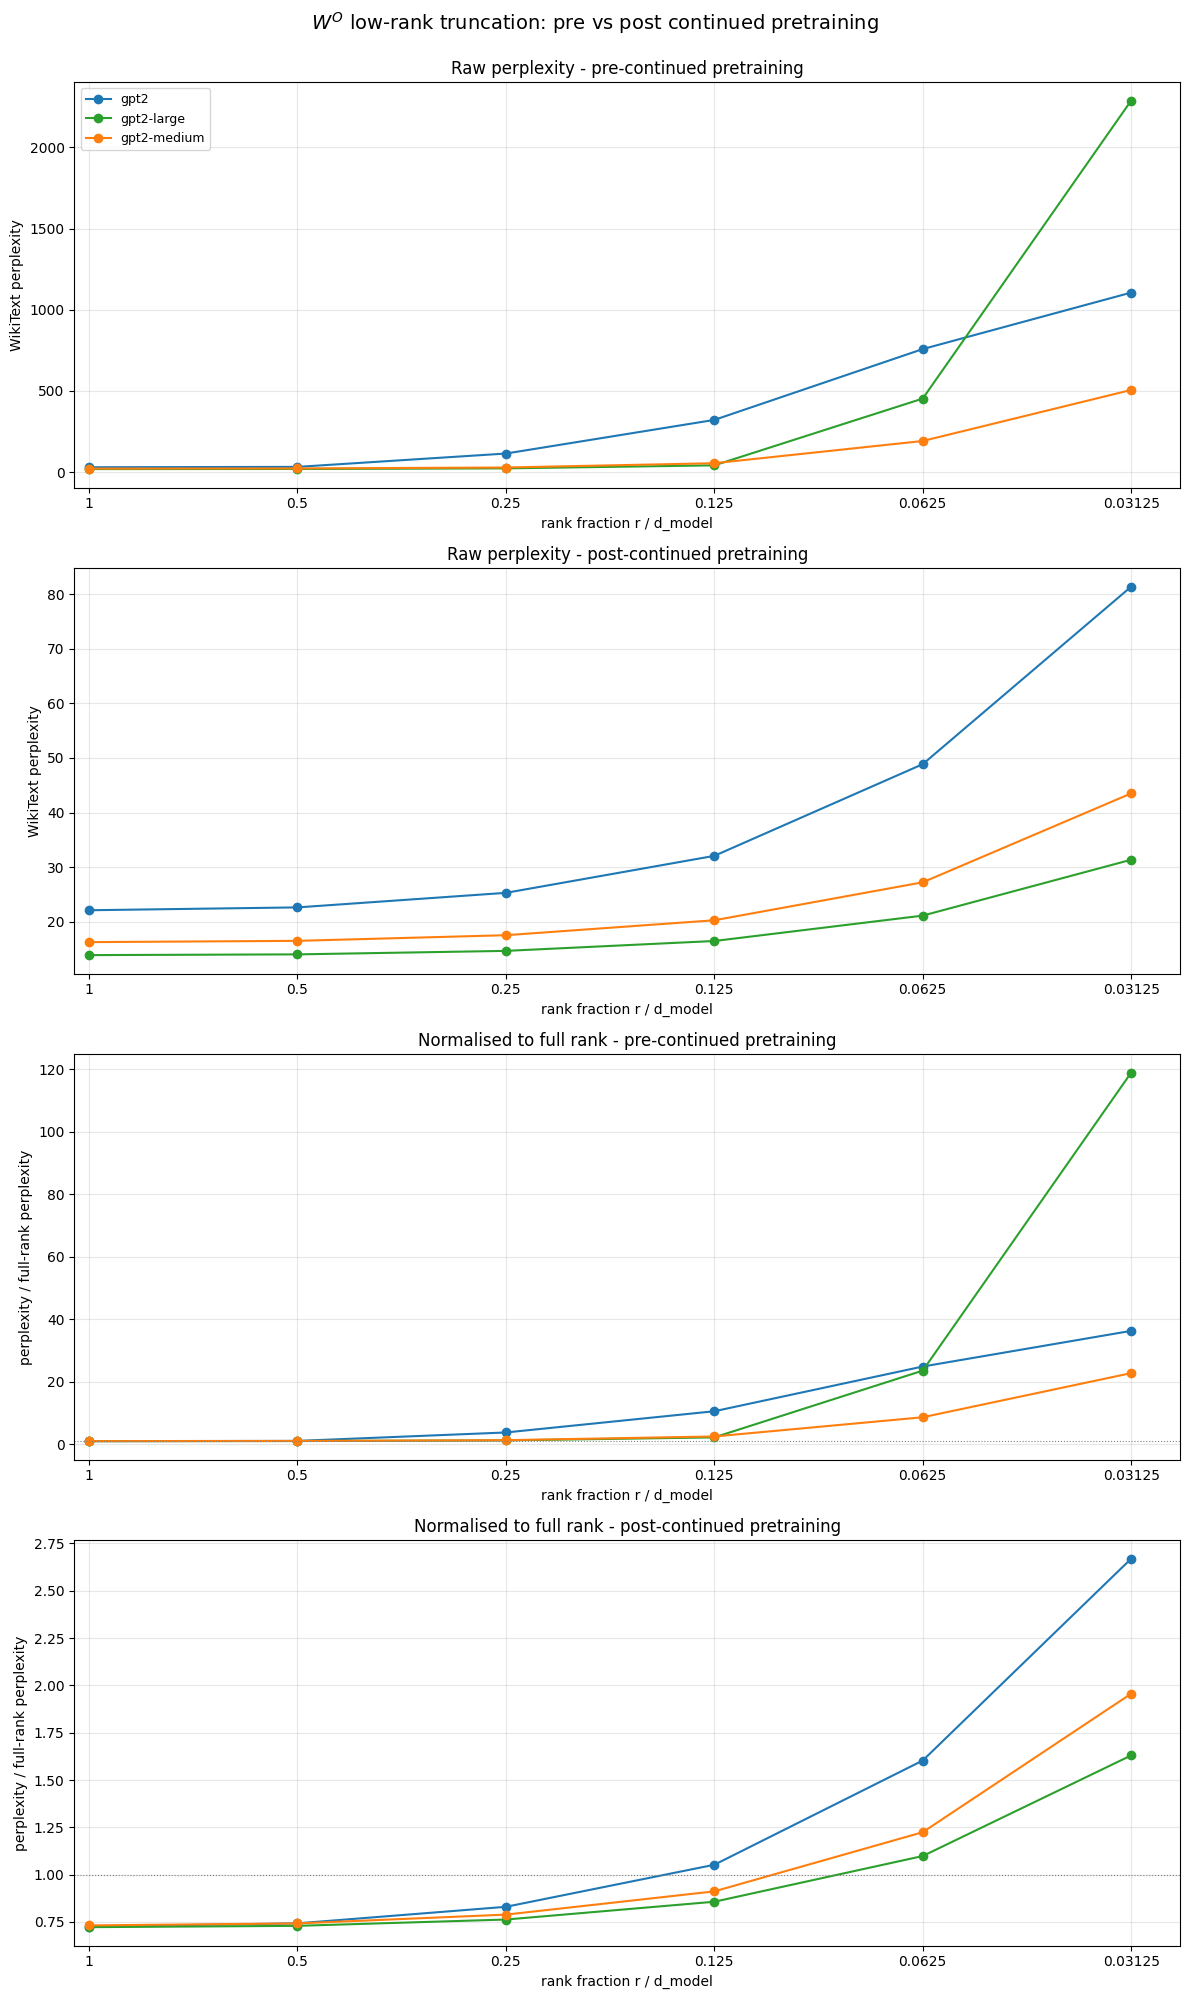

In [8]:
# Plot the results
plot_results(df)

## Conclusion

Examining the first plot above, I can see that GPT2-Small's perplexity increases at a faster rate when compared with GPT2-Medium and GPT2-Large. We can see that GPT2-Medium and GPT2-Large remain relatively close at the start but after a certain point they start to diverge. While GPT2-Small appears to diverge earlier. This is an initial positive sign that there appears to be different rates of increase in model perplexity as compression increases, i.e. as the rank fraction $r$ decreases towards 0. The final compression of the GPT2-Large model also appears to explode.
 
Applying continued pretraining after replacing the output projection matrix with a best rank $r$ approximation matrix helps the model adapt to its new weights matrix, and we can see this in second plot, with overall perplexity values significantly reduced compared to the first plot. The exploding perplexity value for $r=0.03125$ for GPT2-Large has been reduced back down and is now the lowest perplexity across the models for $r=0.03125$. Overall, the three models follow a similar reduction in perplexity as $r$ decreases, with the rate of divergence increasing as $r$ decreases. The divergence is greater for GPT2-Small when compared to GPT2-Medium and Large. This result is in line with what I expected, larger models perform better than medium which in turn perform better than smaller models. It is also worth noting that some of this reduction in perplexity reflects domain adaptation to WikiText-103.

For a fairer comparison, each curve was normalised by their respective baseline models perplexity scores. To ensure that I could compare the pre and post curves, I divided both curves by the pre baseline perplexity values. This normalisation allows me to compare the percentage increase in the models perplexity compared to the models full rank perplexity. Exploring the third plot, it is possible to draw similar conclusions to the first plot, with GPT2-Small starting to diverge earlier than GPT2 Medium and Large.

The forth plot contains the post continued pretraining results normalised on the (pre-continued pretrained) full rank perplexity for their respective model. The results are slightly dampened compared to plot 2, however, the overall conclusions are the same, with the larger models obtaining lower rates of increase in perplexity relative to GPT2-Small as the rate of $W^O$ compression increases. It is also worth noting that some of this reduction in perplexity reflects domain adaptation to WikiText-103.

Overall, these results are positive and suggest that increasing my model size may potentially increase the level of parameter redundancy contained in models attention output projection matrix $W^O$. However, I must note these experiments cannot establish that the differences are due to head count specifically, since the larger models also have more layers and parameters. Therefore, I plan to create an ablation experiment to confirm this by keeping d_model, depth, and parameter count fixed, and vary only n_head. I will then examine the level of change in the perplexity against the number of attention heads across a set of output compression dimensions.